In [ ]:
from eegdash.dataset import DS006848, DS003490, DS003838


# memory - DS006848

In [7]:
import numpy as np
import mne
from pathlib import Path

ROOT = Path("/Users/roman/PycharmProjects/brain_data/data/memory_dataset_DS006848/sub-001/eeg")
WINDOW_SEC = 1.0


def load_and_window(vhdr_path, label):
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)

    sfreq = raw.info["sfreq"]
    window_size = int(WINDOW_SEC * sfreq)

    data = raw.get_data()  # (channels, time)

    X = []
    y = []

    for start in range(0, data.shape[1] - window_size, window_size):
        x = data[:, start:start + window_size]

        # ---- PER-WINDOW NORMALIZATION ----
        x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-10)

        X.append(x)
        y.append(label)

    return X, y


all_X = []
all_y = []

# ---- REST ----
rest_files = list(ROOT.glob("*task-rest*_eeg.vhdr"))
for f in rest_files:
    X, y = load_and_window(f, label=0)
    all_X.extend(X)
    all_y.extend(y)

# ---- ACTIVE (WM) ----
wm_files = list(ROOT.glob("*task-verbalwm*_eeg.vhdr"))
for f in wm_files:
    X, y = load_and_window(f, label=1)
    all_X.extend(X)
    all_y.extend(y)

# ---- FINAL ARRAYS ----
X = np.array(all_X)  # (windows, channels, time)
y = np.array(all_y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class balance:", np.bincount(y))

X shape: (6477, 65, 1000)
y shape: (6477,)
class balance: [ 732 5745]


## features

In [6]:
from scipy.signal import welch, butter, filtfilt

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

def compute_psd_batch(windows, sfreq):
    freqs, psd = welch(
        windows,
        fs=sfreq,
        nperseg=int(sfreq*2),
        axis=2
    )
    return freqs, psd

def bandpower_from_psd(freqs, psd):
    total_power = np.trapezoid(psd, freqs, axis=2)
    feats = []

    for low, high in bands.values():
        idx = (freqs >= low) & (freqs <= high)
        band_power = np.trapezoid(psd[:, :, idx], freqs[idx], axis=2)
        feats.append(band_power / (total_power + 1e-10))

    return np.concatenate(feats, axis=1)

def bandpass(data, sfreq, low, high):
    b, a = butter(4, [low/(sfreq/2), high/(sfreq/2)], btype='band')
    return filtfilt(b, a, data, axis=1)

def fast_connectivity(window):
    corr = np.corrcoef(window)
    return corr[np.triu_indices_from(corr, k=1)]

def coherence_band_fast(window, sfreq, band):
    filtered = bandpass(window, sfreq, band[0], band[1])
    return fast_connectivity(filtered)

def fast_band_connectivity(windows, sfreq, band):
    b, a = butter(4, [band[0]/(sfreq/2), band[1]/(sfreq/2)], btype='band')

    feats = []
    for w in windows:
        f = filtfilt(b, a, w, axis=1)
        corr = np.corrcoef(f)
        feats.append(corr[np.triu_indices_from(corr, k=1)])

    return np.array(feats)

In [4]:
def spectral_entropy(psd):
    psd_norm = psd / (np.sum(psd, axis=-1, keepdims=True) + 1e-10)
    return -np.sum(psd_norm * np.log(psd_norm + 1e-10), axis=-1)

def hjorth_params(signal):
    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var0 = np.var(signal)
    var1 = np.var(diff1)
    var2 = np.var(diff2)

    activity = var0
    mobility = np.sqrt(var1 / (var0 + 1e-10))
    complexity = np.sqrt(var2 / (var1 + 1e-10)) / (mobility + 1e-10)

    return np.array([activity, mobility, complexity])

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(5181, 65, 1000) (1296, 65, 1000)
0.8868944219262691 0.8873456790123457


In [9]:
# ======================
# Fast feature extraction for all bands
# ======================
def extract_features_fast(windows, sfreq):
    """
    windows: array (n_windows, n_channels, n_times)
    raw_info: MNE Raw.info
    sfreq: sampling frequency
    """
    # --- Precompute PSD for all windows ---
    freqs, psd = compute_psd_batch(windows, sfreq)  # shape: (n_windows, n_channels, n_freqs)

    # --- Bandpower features ---
    bp = bandpower_from_psd(freqs, psd)  # returns (n_windows, n_channels * n_bands)

    # --- Spectral entropy per channel ---
    ent = spectral_entropy(psd)  # (n_windows, n_channels)

    # --- Connectivity for all bands ---
    bands_list = {
        "delta": (1,4),
        "theta": (4,8),
        "alpha": (8,13),
        "beta":  (13,30),
        "gamma": (30,40)
    }

    # conn_features = []
    # for band_name, band_range in bands_list.items():
    #     # Compute coherence for this band for each window
    #     conn_band = np.array([coherence_band_fast(w, sfreq, band_range) for w in windows])
    #     conn_features.append(conn_band)
    # conn_all = np.concatenate(conn_features, axis=1)  # shape: (n_windows, n_conn * n_bands)

    conn_features = []
    for band_name, band_range in bands_list.items():
        conn_features.append(fast_band_connectivity(windows, sfreq, band_range))

    conn_all = np.concatenate(conn_features, axis=1)

    # --- Hjorth parameters per channel ---
    hjorth_feats = np.array([
        np.concatenate([hjorth_params(ch) for ch in w])
        for w in windows
    ])  # shape: (n_windows, n_channels*3)

    X = np.concatenate([bp, ent, conn_all, hjorth_feats], axis=1)
    return X

sfreq = 1000
X_train_feat = extract_features_fast(X_train, sfreq)
X_test_feat  = extract_features_fast(X_test, sfreq)

print(X_train_feat.shape)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 2000 is greater than input length  = 1000, using nperseg = 1000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(5181, 10985)


In [10]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.int64(1): 4595, np.int64(0): 586})


In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train_feat, y_train)

preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:,1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       146
           1       1.00      1.00      1.00      1150

    accuracy                           1.00      1296
   macro avg       1.00      0.99      0.99      1296
weighted avg       1.00      1.00      1.00      1296

ROC AUC: 1.0


# CPT - continuous performance task - DS006040

In [75]:
import numpy as np
import mne
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="The data contains 'boundary' events",
    category=RuntimeWarning
)

ROOT = Path("/Users/roman/PycharmProjects/brain_data/experiments_eeg/attention_dataset/derivatives/sub-001/eeg")
WINDOW_SEC = 1.0


def get_label_from_file(path):
    name = path.name.upper()

    # REST
    if "TASK-EO" in name or "TASK-EC" in name:
        return 0

    # ATTENTION
    if "TASK-GRAD" in name and "IMGRAD" not in name:
        return 1

    return None

def load_and_window(set_path, label):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # ---- RESAMPLE HERE ----
    raw.resample(256)   # or 512 / 1000 if you prefer

    sfreq = raw.info["sfreq"]
    window_size = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    # ---- get boundary samples ----
    boundary_samples = set()

    for ann in raw.annotations:
        if "boundary" in ann["description"].lower():
            s = int(ann["onset"] * sfreq)
            boundary_samples.add(s)

    X, y = [], []

    for start in range(0, data.shape[1] - window_size, window_size):
        end = start + window_size

        if any(start <= b < end for b in boundary_samples):
            continue

        x = data[:, start:end]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x.astype(np.float32))   # extra memory reduction
        y.append(label)

    return X, y


all_X, all_y = [], []

for set_file in ROOT.rglob("*_eeg.set"):
    label = get_label_from_file(set_file)
    if label is None:
        continue

    # print("using:", set_file.name, "->", label)

    X, y = load_and_window(set_file, label)

    all_X.extend(X)
    all_y.extend(y)


X = np.array(all_X)
y = np.array(all_y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class balance:", np.bincount(y))

KeyboardInterrupt: 

In [23]:
from scipy.signal import welch, butter, filtfilt

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

def compute_psd_batch(windows, sfreq):
    freqs, psd = welch(
        windows,
        fs=sfreq,
        nperseg=int(sfreq*2),
        axis=2
    )
    return freqs, psd

def bandpower_from_psd(freqs, psd):
    total_power = np.trapezoid(psd, freqs, axis=2)
    feats = []

    for low, high in bands.values():
        idx = (freqs >= low) & (freqs <= high)
        band_power = np.trapezoid(psd[:, :, idx], freqs[idx], axis=2)
        feats.append(band_power / (total_power + 1e-10))

    return np.concatenate(feats, axis=1)

def bandpass(data, sfreq, low, high):
    b, a = butter(4, [low/(sfreq/2), high/(sfreq/2)], btype='band')
    return filtfilt(b, a, data, axis=1)

def fast_connectivity(window):
    corr = np.corrcoef(window)
    return corr[np.triu_indices_from(corr, k=1)]

def coherence_band_fast(window, sfreq, band):
    filtered = bandpass(window, sfreq, band[0], band[1])
    return fast_connectivity(filtered)

def fast_band_connectivity(windows, sfreq, band):
    b, a = butter(4, [band[0]/(sfreq/2), band[1]/(sfreq/2)], btype='band')

    feats = []
    for w in windows:
        f = filtfilt(b, a, w, axis=1)
        corr = np.corrcoef(f)
        feats.append(corr[np.triu_indices_from(corr, k=1)])

    return np.array(feats)

In [24]:
def spectral_entropy(psd):
    psd_norm = psd / (np.sum(psd, axis=-1, keepdims=True) + 1e-10)
    return -np.sum(psd_norm * np.log(psd_norm + 1e-10), axis=-1)

def hjorth_params(signal):
    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var0 = np.var(signal)
    var1 = np.var(diff1)
    var2 = np.var(diff2)

    activity = var0
    mobility = np.sqrt(var1 / (var0 + 1e-10))
    complexity = np.sqrt(var2 / (var1 + 1e-10)) / (mobility + 1e-10)

    return np.array([activity, mobility, complexity])

In [25]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(3750, 64, 256) (938, 64, 256)
0.5869333333333333 0.5863539445628998


In [37]:
from eegdash.dataset import DS006040

dataset = DS006040(cache_dir="./data")
# Get the raw object of the first recording
raw_rest = dataset.datasets[0].raw
raw_rest.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'Fz',
 'Cz',
 'Pz',
 'Oz',
 'FC1',
 'FC2',
 'CP1',
 'CP2',
 'FC5',
 'FC6',
 'CP5',
 'CP6',
 'TP9',
 'TP10',
 'POz',
 'ECG',
 'F1',
 'F2',
 'C1',
 'C2',
 'P1',
 'P2',
 'AF3',
 'AF4',
 'FC3',
 'FC4',
 'CP3',
 'CP4',
 'PO3',
 'PO4',
 'F5',
 'F6',
 'C5',
 'C6',
 'P5',
 'P6',
 'AF7',
 'AF8',
 'FT7',
 'FT8',
 'TP7',
 'TP8',
 'PO7',
 'PO8',
 'FT9',
 'FT10',
 'Fpz',
 'CPz']

In [4]:
from eegdash.dataset import DS006040

dataset = DS006040(cache_dir="./data")
# Get the raw object of the first recording
raw = dataset.datasets[0].raw
sfreq = raw.info["sfreq"]
sfreq

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5000.0

In [26]:
# ======================
# Fast feature extraction for all bands
# ======================
def extract_features_fast(windows, sfreq):
    """
    windows: array (n_windows, n_channels, n_times)
    raw_info: MNE Raw.info
    sfreq: sampling frequency
    """
    # --- Precompute PSD for all windows ---
    freqs, psd = compute_psd_batch(windows, sfreq)  # shape: (n_windows, n_channels, n_freqs)

    # --- Bandpower features ---
    bp = bandpower_from_psd(freqs, psd)  # returns (n_windows, n_channels * n_bands)

    # --- Spectral entropy per channel ---
    ent = spectral_entropy(psd)  # (n_windows, n_channels)

    # --- Connectivity for all bands ---
    bands_list = {
        "delta": (1,4),
        "theta": (4,8),
        "alpha": (8,13),
        "beta":  (13,30),
        "gamma": (30,40)
    }

    # conn_features = []
    # for band_name, band_range in bands_list.items():
    #     # Compute coherence for this band for each window
    #     conn_band = np.array([coherence_band_fast(w, sfreq, band_range) for w in windows])
    #     conn_features.append(conn_band)
    # conn_all = np.concatenate(conn_features, axis=1)  # shape: (n_windows, n_conn * n_bands)

    conn_features = []
    for band_name, band_range in bands_list.items():
        conn_features.append(fast_band_connectivity(windows, sfreq, band_range))

    conn_all = np.concatenate(conn_features, axis=1)

    # --- Hjorth parameters per channel ---
    hjorth_feats = np.array([
        np.concatenate([hjorth_params(ch) for ch in w])
        for w in windows
    ])  # shape: (n_windows, n_channels*3)

    X = np.concatenate([bp, ent, conn_all, hjorth_feats], axis=1)
    return X

X_train_feat = extract_features_fast(X_train, 256)
X_test_feat  = extract_features_fast(X_test, 256)

print(X_train_feat.shape)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 256, using nperseg = 256
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(3750, 10656)


In [27]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.int64(1): 2201, np.int64(0): 1549})


## model

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train_feat, y_train)

preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:,1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       388
           1       0.98      0.99      0.98       550

    accuracy                           0.98       938
   macro avg       0.98      0.98      0.98       938
weighted avg       0.98      0.98      0.98       938

ROC AUC: 0.9978584817244611


# mind wandering - DS001787

In [14]:
from eegdash.dataset import DS001787

dataset = DS001787(cache_dir="./data")
# Get the raw object of the first recording
raw = dataset.datasets[0].raw
print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, A12, A13, A14, ...
 chs: 79 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 52.0 Hz
 meas_date: 2014-04-14 08:01:06 UTC
 nchan: 80
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | >
>


In [52]:
X.shape

(4688, 64, 256)

In [53]:
y

array([0, 0, 0, ..., 0, 0, 0], shape=(4688,))

In [56]:
X_rest = X[y == 0]
y_rest = y[y == 0]
print(X_rest.shape, np.bincount(y_rest))

(1937, 64, 256) [1937]


In [29]:
from eegdash.dataset import DS001787

dataset = DS001787(cache_dir="./data")

raw = dataset.datasets[0].raw
raw.load_data()
raw.info["sfreq"]

Reading 0 ... 850431  =      0.000 ...  3321.996 secs...


256.0

In [43]:
import mne
import numpy as np
from eegdash.dataset import DS001787

WINDOW_SEC = 1.0

def window_raw(raw, label):
    sfreq = raw.info["sfreq"]
    win = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    X, y = [], []

    for start in range(0, data.shape[1] - win, win):
        x = data[:, start:start + win]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x)
        y.append(label)

    return X, y


med_dataset = DS001787(cache_dir="./data")

# ---- use only ONE subject ----
rec = med_dataset.datasets[0]   # change index if needed
raw = rec.raw
raw.pick(raw.ch_names[:64])

raw.load_data()

med_X, med_y = window_raw(raw, label=1)

med_X = np.array(med_X)
med_y = np.array(med_y)

print(med_X.shape, np.bincount(med_y))

Reading 0 ... 850431  =      0.000 ...  3321.996 secs...
(3321, 64, 256) [   0 3321]


In [57]:
X_rest.shape, med_X.shape

((1937, 64, 256), (3321, 64, 256))

In [58]:
X_new = np.concatenate([X_rest, med_X], axis=0)
y_new = np.concatenate([y_rest, med_y], axis=0)

print(X_new.shape, np.bincount(y_new))

(5258, 64, 256) [1937 3321]


In [61]:
X_new.shape, y_new.shape

((5258, 64, 256), (5258,))

In [62]:
from sklearn.model_selection import train_test_split
import numpy as np

X_new = np.array(X_new)
y_new = np.array(y_new)

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_new
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(4206, 64, 256) (1052, 64, 256)
0.6317165953399905 0.6311787072243346


In [63]:
# ======================
# Fast feature extraction for all bands
# ======================
def extract_features_fast(windows, sfreq):
    """
    windows: array (n_windows, n_channels, n_times)
    raw_info: MNE Raw.info
    sfreq: sampling frequency
    """
    # --- Precompute PSD for all windows ---
    freqs, psd = compute_psd_batch(windows, sfreq)  # shape: (n_windows, n_channels, n_freqs)

    # --- Bandpower features ---
    bp = bandpower_from_psd(freqs, psd)  # returns (n_windows, n_channels * n_bands)

    # --- Spectral entropy per channel ---
    ent = spectral_entropy(psd)  # (n_windows, n_channels)

    # --- Connectivity for all bands ---
    bands_list = {
        "delta": (1,4),
        "theta": (4,8),
        "alpha": (8,13),
        "beta":  (13,30),
        "gamma": (30,40)
    }

    # conn_features = []
    # for band_name, band_range in bands_list.items():
    #     # Compute coherence for this band for each window
    #     conn_band = np.array([coherence_band_fast(w, sfreq, band_range) for w in windows])
    #     conn_features.append(conn_band)
    # conn_all = np.concatenate(conn_features, axis=1)  # shape: (n_windows, n_conn * n_bands)

    conn_features = []
    for band_name, band_range in bands_list.items():
        conn_features.append(fast_band_connectivity(windows, sfreq, band_range))

    conn_all = np.concatenate(conn_features, axis=1)

    # --- Hjorth parameters per channel ---
    hjorth_feats = np.array([
        np.concatenate([hjorth_params(ch) for ch in w])
        for w in windows
    ])  # shape: (n_windows, n_channels*3)

    X = np.concatenate([bp, ent, conn_all, hjorth_feats], axis=1)
    return X

X_train_feat = extract_features_fast(X_train, 256)
X_test_feat  = extract_features_fast(X_test, 256)

print(X_train_feat.shape)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 256, using nperseg = 256
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(4206, 10656)


In [64]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.int64(1): 2657, np.int64(0): 1549})


## model

In [65]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train_feat, y_train)

preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:,1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       388
           1       1.00      1.00      1.00       664

    accuracy                           1.00      1052
   macro avg       1.00      1.00      1.00      1052
weighted avg       1.00      1.00      1.00      1052

ROC AUC: 1.0


# imaginary motor task - DS003810

This dataset consists of electroencephalography (EEG) signals adquired with a low-cost consumer-grade device. The 10 participants had no previous BCI experience. The BCI protocol consisted of two conditions, namely the kinesthetic imagination of grasping movement (MI) of the dominant hand and rest/idle condition.Five protocol runs were asked to be performed by the user. The first run, called RUN0, involved real grasping movement in order to better explain the protocol and to help the subject to focus on the sensation of making the movement. The rest of the runs (RUN1-RUN4) were equal, consisting of MI vs.Rest conditions. The EMG signals of the dominant hand was adquired for protocol control. During acquisition, the EEG signals were filtered between 0.5 and 45 Hz with a 3rd order Butterworth bandpass-filter.

In [66]:
from eegdash.dataset import DS003810

dataset = DS003810(cache_dir="./data")
# Get the raw object of the first recording
raw = dataset.datasets[0].raw
print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: Pz, Cz, T6, T4, F8, P4, C4, F4, Fz, T5, T3, F7, P3, C3, F3
 chs: 15 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 62.5 Hz
 meas_date: 2021-09-16 13:50:31 UTC
 nchan: 15
 projs: []
 sfreq: 125.0 Hz
 subject_info: <subject_info | >
>


In [71]:
raw = dataset.datasets[0].raw
print(set(raw.annotations.description))

{np.str_('OVTK_StimulationId_Beep'), np.str_('OVTK_GDF_End_Of_Session'), np.str_('OVTK_GDF_Cross_On_Screen'), np.str_('OVTK_StimulationId_BaselineStart'), np.str_('OVTK_GDF_Tongue'), np.str_('OVTK_StimulationId_BaselineStop'), np.str_('OVTK_GDF_Feedback_Continuous'), np.str_('OVTK_GDF_Right'), np.str_('OVTK_GDF_Incorrect'), np.str_('OVTK_StimulationId_ExperimentStop'), np.str_('OVTK_GDF_Correct'), np.str_('OVTK_StimulationId_ExperimentStart'), np.str_('OVTK_GDF_Start_Of_Trial'), np.str_('OVTK_StimulationId_Train'), np.str_('OVTK_GDF_End_Of_Trial')}


In [68]:
raw.info["sfreq"]

125.0

we have to resample rest data to 125 here

In [85]:
import numpy as np
import mne
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="The data contains 'boundary' events",
    category=RuntimeWarning
)

ROOT = Path("/Users/roman/PycharmProjects/brain_data/experiments_eeg/attention_dataset/derivatives/sub-001/eeg")
WINDOW_SEC = 1.0


def get_label_from_file(path):
    name = path.name.upper()

    # REST
    if "TASK-EO" in name or "TASK-EC" in name:
        return 0

    # ATTENTION
    if "TASK-GRAD" in name and "IMGRAD" not in name:
        return 1

    return None

def load_and_window(set_path, label):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # ---- RESAMPLE HERE ----
    raw.resample(125)   # or 512 / 1000 if you prefer

    sfreq = raw.info["sfreq"]
    window_size = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    # ---- get boundary samples ----
    boundary_samples = set()

    for ann in raw.annotations:
        if "boundary" in ann["description"].lower():
            s = int(ann["onset"] * sfreq)
            boundary_samples.add(s)

    X, y = [], []

    for start in range(0, data.shape[1] - window_size, window_size):
        end = start + window_size

        if any(start <= b < end for b in boundary_samples):
            continue

        x = data[:, start:end]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x.astype(np.float32))   # extra memory reduction
        y.append(label)

    return X, y


all_X, all_y = [], []

for set_file in ROOT.rglob("*_eeg.set"):
    label = get_label_from_file(set_file)
    if label is None:
        continue

    # print("using:", set_file.name, "->", label)

    X, y = load_and_window(set_file, label)

    all_X.extend(X)
    all_y.extend(y)


X = np.array(all_X)
y = np.array(all_y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class balance:", np.bincount(y))

X shape: (4688, 64, 125)
y shape: (4688,)
class balance: [1937 2751]


In [86]:
X_rest = X[y == 0]
y_rest = y[y == 0]
print(X_rest.shape, np.bincount(y_rest))

(1937, 64, 125) [1937]


In [78]:
import numpy as np
from eegdash.dataset import DS003810

WINDOW_SEC = 1.0
KEEP_CHANNELS = 64

dataset = DS003810(cache_dir="./data")

def extract_windows(raw):
    sfreq = raw.info["sfreq"]
    win = int(WINDOW_SEC * sfreq)

    data = raw.get_data()[:KEEP_CHANNELS]

    X, y = [], []

    for ann in raw.annotations:
        desc = ann["description"]
        start = int(ann["onset"] * sfreq)

        # REST
        if desc == "OVTK_StimulationId_BaselineStart":
            X.append(data[:, start:start+win])
            y.append(0)

        # TASK (motor imagery)
        elif desc in ["OVTK_GDF_Right", "OVTK_GDF_Tongue"]:
            X.append(data[:, start:start+win])
            y.append(1)

    return np.array(X), np.array(y)


X_all, y_all = [], []

for rec in dataset.datasets:
    X, y = extract_windows(rec.raw)
    if len(X):
        X_all.append(X)
        y_all.append(y)

X_active = np.concatenate(X_all)
y_active = np.concatenate(y_all)

In [81]:
y_rest.shape, y_active.shape

((1937,), (1740,))

In [87]:
X_rest = X_rest[:, :15, :]

In [79]:
X_rest.shape, X_active.shape

((1937, 64, 256), (1740, 15, 125))

In [88]:
X_rest.shape, X_active.shape

((1937, 15, 125), (1740, 15, 125))

In [89]:
X_new = np.concatenate([X_rest, X_active], axis=0)
y_new = np.concatenate([y_rest, y_active], axis=0)

print(X_new.shape, np.bincount(y_new))

(3677, 15, 125) [1987 1690]


## train test split

In [90]:
from sklearn.model_selection import train_test_split
import numpy as np

X_new = np.array(X_new)
y_new = np.array(y_new)

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_new
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(2941, 15, 125) (736, 15, 125)
0.4597075824549473 0.4592391304347826


In [94]:
X_train_feat = extract_features_fast(X_train, 125)
X_test_feat  = extract_features_fast(X_test, 125)

print(X_train_feat.shape)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 250 is greater than input length  = 125, using nperseg = 125
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(2941, 660)


In [95]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.int64(0): 1589, np.int64(1): 1352})


## model

In [96]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train_feat, y_train)

preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:,1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       398
           1       0.98      1.00      0.99       338

    accuracy                           0.99       736
   macro avg       0.99      0.99      0.99       736
weighted avg       0.99      0.99      0.99       736

ROC AUC: 0.9945808926288247


# try imaginary motor task on CPT

In [101]:
import numpy as np
import mne
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="The data contains 'boundary' events",
    category=RuntimeWarning
)

ROOT = Path("/Users/roman/PycharmProjects/brain_data/experiments_eeg/attention_dataset/derivatives/sub-001/eeg")
WINDOW_SEC = 1.0


def get_label_from_file(path):
    name = path.name.upper()

    # REST
    if "TASK-EO" in name or "TASK-EC" in name:
        return 0

    # ATTENTION
    if "TASK-GRAD" in name and "IMGRAD" not in name:
        return 1

    return None

def load_and_window(set_path, label):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # ---- RESAMPLE HERE ----
    raw.resample(125)   # or 512 / 1000 if you prefer

    sfreq = raw.info["sfreq"]
    window_size = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    # ---- get boundary samples ----
    boundary_samples = set()

    for ann in raw.annotations:
        if "boundary" in ann["description"].lower():
            s = int(ann["onset"] * sfreq)
            boundary_samples.add(s)

    X, y = [], []

    for start in range(0, data.shape[1] - window_size, window_size):
        end = start + window_size

        if any(start <= b < end for b in boundary_samples):
            continue

        x = data[:, start:end]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x.astype(np.float32))   # extra memory reduction
        y.append(label)

    return X, y


all_X, all_y = [], []

for set_file in ROOT.rglob("*_eeg.set"):
    label = get_label_from_file(set_file)
    if label is None:
        continue

    # print("using:", set_file.name, "->", label)

    X, y = load_and_window(set_file, label)

    all_X.extend(X)
    all_y.extend(y)


X = np.array(all_X)
y = np.array(all_y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class balance:", np.bincount(y))

X shape: (4688, 64, 125)
y shape: (4688,)
class balance: [1937 2751]


In [106]:
X = X[:, :15, :]

In [107]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(3750, 15, 125) (938, 15, 125)
0.5869333333333333 0.5863539445628998


also use 125 freq here because we had it in motor task

In [108]:
X_train_feat = extract_features_fast(X_train, 125)
X_test_feat  = extract_features_fast(X_test, 125)

print(X_train_feat.shape)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 250 is greater than input length  = 125, using nperseg = 125
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(3750, 660)


In [109]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.int64(1): 2201, np.int64(0): 1549})


In [110]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:,1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.38      0.80      0.51       388
           1       0.34      0.07      0.12       550

    accuracy                           0.37       938
   macro avg       0.36      0.44      0.32       938
weighted avg       0.36      0.37      0.28       938

ROC AUC: 0.33729615745079666


# all 4 datasets at once

## memory

In [170]:
import numpy as np
import mne
from pathlib import Path

ROOT = Path("/Users/roman/PycharmProjects/brain_data/data/memory_dataset_DS006848/sub-001/eeg")
WINDOW_SEC = 1.0


def load_and_window(vhdr_path, label):
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
    raw.resample(125)   # or 512 / 1000 if you prefer

    sfreq = raw.info["sfreq"]
    window_size = int(WINDOW_SEC * sfreq)

    data = raw.get_data()  # (channels, time)

    X = []
    y = []

    for start in range(0, data.shape[1] - window_size, window_size):
        x = data[:, start:start + window_size]

        # ---- PER-WINDOW NORMALIZATION ----
        x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-10)

        X.append(x)
        y.append(label)

    return X, y


all_X = []
all_y = []

# ---- REST ----
rest_files = list(ROOT.glob("*task-rest*_eeg.vhdr"))
for f in rest_files:
    X, y = load_and_window(f, label=0)
    all_X.extend(X)
    all_y.extend(y)

# ---- ACTIVE (WM) ----
wm_files = list(ROOT.glob("*task-verbalwm*_eeg.vhdr"))
for f in wm_files:
    X, y = load_and_window(f, label=1)
    all_X.extend(X)
    all_y.extend(y)

# ---- FINAL ARRAYS ----
X = np.array(all_X)  # (windows, channels, time)
y = np.array(all_y)

X = X[:, :15, :]

X_mem = X[y == 1]
y_mem = y[y == 1]

X_rest_1 = X[y == 0]
y_rest_1 = y[y == 0]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class balance:", np.bincount(y))

X shape: (6477, 15, 125)
y shape: (6477,)
class balance: [ 732 5745]


## cpt

In [171]:
import numpy as np
import mne
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="The data contains 'boundary' events",
    category=RuntimeWarning
)

ROOT = Path("/Users/roman/PycharmProjects/brain_data/experiments_eeg/attention_dataset/derivatives/sub-001/eeg")
WINDOW_SEC = 1.0


def get_label_from_file(path):
    name = path.name.upper()

    # REST
    if "TASK-EO" in name or "TASK-EC" in name:
        return 0

    # ATTENTION
    if "TASK-GRAD" in name and "IMGRAD" not in name:
        return 1

    return None

def load_and_window(set_path, label):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # ---- RESAMPLE HERE ----
    raw.resample(125)   # or 512 / 1000 if you prefer

    sfreq = raw.info["sfreq"]
    window_size = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    # ---- get boundary samples ----
    boundary_samples = set()

    for ann in raw.annotations:
        if "boundary" in ann["description"].lower():
            s = int(ann["onset"] * sfreq)
            boundary_samples.add(s)

    X, y = [], []

    for start in range(0, data.shape[1] - window_size, window_size):
        end = start + window_size

        if any(start <= b < end for b in boundary_samples):
            continue

        x = data[:, start:end]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x.astype(np.float32))   # extra memory reduction
        y.append(label)

    return X, y


all_X, all_y = [], []

for set_file in ROOT.rglob("*_eeg.set"):
    label = get_label_from_file(set_file)
    if label is None:
        continue

    # print("using:", set_file.name, "->", label)

    X, y = load_and_window(set_file, label)

    all_X.extend(X)
    all_y.extend(y)

X = np.array(all_X)
y = np.array(all_y)

X = X[:, :15, :]

X_cpt = X[y == 1]
y_cpt = y[y == 1]

X_rest_2 = X[y == 0]
y_rest_2 = y[y == 0]

X_cpt.shape, y_cpt.shape

((2751, 15, 125), (2751,))

## mind wandering

In [172]:
from eegdash.dataset import DS001787

dataset = DS001787(cache_dir="./data")
# Get the raw object of the first recording
raw = dataset.datasets[0].raw
print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, A12, A13, A14, ...
 chs: 79 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 52.0 Hz
 meas_date: 2014-04-14 08:01:06 UTC
 nchan: 80
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | >
>


In [173]:
import mne
import numpy as np
from eegdash.dataset import DS001787

WINDOW_SEC = 1.0

def window_raw(raw, label):
    raw.resample(125)
    sfreq = raw.info["sfreq"]
    win = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    X, y = [], []

    for start in range(0, data.shape[1] - win, win):
        x = data[:, start:start + win]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x)
        y.append(label)

    return X, y


med_dataset = DS001787(cache_dir="./data")

# ---- use only ONE subject ----
rec = med_dataset.datasets[0]   # change index if needed
raw = rec.raw
raw.pick(raw.ch_names[:64])

raw.load_data()

X, y = window_raw(raw, label=1)

X = np.array(X)
y = np.array(y)

X = X[:, :15, :]

med_X = X[y == 1]
med_y = y[y == 1]

X_rest_3 = X[y == 0]
y_rest_3 = y[y == 0]

med_X.shape, med_y.shape

Reading 0 ... 850431  =      0.000 ...  3321.996 secs...


((3321, 15, 125), (3321,))

## imaginary motor task

In [174]:
from eegdash.dataset import DS003810

dataset = DS003810(cache_dir="./data")
# Get the raw object of the first recording
raw = dataset.datasets[0].raw
print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: Pz, Cz, T6, T4, F8, P4, C4, F4, Fz, T5, T3, F7, P3, C3, F3
 chs: 15 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 62.5 Hz
 meas_date: 2021-09-16 13:50:31 UTC
 nchan: 15
 projs: []
 sfreq: 125.0 Hz
 subject_info: <subject_info | >
>


In [175]:
import numpy as np
import mne
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="The data contains 'boundary' events",
    category=RuntimeWarning
)

ROOT = Path("/Users/roman/PycharmProjects/brain_data/experiments_eeg/attention_dataset/derivatives/sub-001/eeg")
WINDOW_SEC = 1.0


def get_label_from_file(path):
    name = path.name.upper()

    # REST
    if "TASK-EO" in name or "TASK-EC" in name:
        return 0

    # ATTENTION
    if "TASK-GRAD" in name and "IMGRAD" not in name:
        return 1

    return None

def load_and_window(set_path, label):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # ---- RESAMPLE HERE ----
    raw.resample(125)   # or 512 / 1000 if you prefer

    sfreq = raw.info["sfreq"]
    window_size = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    # ---- get boundary samples ----
    boundary_samples = set()

    for ann in raw.annotations:
        if "boundary" in ann["description"].lower():
            s = int(ann["onset"] * sfreq)
            boundary_samples.add(s)

    X, y = [], []

    for start in range(0, data.shape[1] - window_size, window_size):
        end = start + window_size

        if any(start <= b < end for b in boundary_samples):
            continue

        x = data[:, start:end]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x.astype(np.float32))   # extra memory reduction
        y.append(label)

    return X, y


all_X, all_y = [], []

for set_file in ROOT.rglob("*_eeg.set"):
    label = get_label_from_file(set_file)
    if label is None:
        continue

    # print("using:", set_file.name, "->", label)

    X, y = load_and_window(set_file, label)

    all_X.extend(X)
    all_y.extend(y)


X = np.array(all_X)
y = np.array(all_y)

X = X[:, :15, :]

X_mot = X[y == 1]
y_mot = y[y == 1]

X_rest_4 = X[y == 0]
y_rest_4 = y[y == 0]

X_mot.shape, y_mot.shape

((2751, 15, 125), (2751,))

## concatenation

In [ ]:
X_mem, X_cpt, med_X, X_mot

In [139]:
X_mem.shape

(5745, 15, 125)

In [140]:
X_cpt.shape

(2751, 15, 125)

In [176]:
import numpy as np

# active (task) datasets
X_active = [
    X_mem,
    X_cpt,
    med_X,
    X_mot
]

# rest datasets
X_rest_full = [
    X_rest_1,
    X_rest_2,
    X_rest_3,
    X_rest_4
]

# concatenate
X_active = np.concatenate(X_active, axis=0)
X_rest_full = np.concatenate(X_rest_full, axis=0)

# labels
y_active = np.ones(len(X_active), dtype=int)
y_rest = np.zeros(len(X_rest_full), dtype=int)

# final dataset
X_final = np.concatenate([X_active, X_rest_full], axis=0)
y_final = np.concatenate([y_active, y_rest], axis=0)

print("X shape:", X_final.shape)
print("y shape:", y_final.shape)
print("class balance:", np.bincount(y_final))

X shape: (19174, 15, 125)
y shape: (19174,)
class balance: [ 4606 14568]


## train test split

In [177]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_final
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(15339, 15, 125) (3835, 15, 125)
0.7597626963948106 0.7598435462842242


## features

In [178]:
X_train_feat = extract_features_fast(X_train, 125)
X_test_feat  = extract_features_fast(X_test, 125)

print(X_train_feat.shape)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 250 is greater than input length  = 125, using nperseg = 125
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(15339, 645)


In [179]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.int64(1): 11654, np.int64(0): 3685})


## model

In [180]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train_feat, y_train)

preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:,1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       921
           1       0.96      0.98      0.97      2914

    accuracy                           0.95      3835
   macro avg       0.94      0.93      0.94      3835
weighted avg       0.95      0.95      0.95      3835

ROC AUC: 0.9885524000724348


## try on some tasks

### mind wandering DS001787 - new participant

In [150]:
import mne
import numpy as np
from eegdash.dataset import DS001787

WINDOW_SEC = 1.0

def window_raw(raw, label):
    raw.resample(125)   # or 512 / 1000 if you prefer
    sfreq = raw.info["sfreq"]
    win = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    X, y = [], []

    for start in range(0, data.shape[1] - win, win):
        x = data[:, start:start + win]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x)
        y.append(label)

    return X, y


med_dataset = DS001787(cache_dir="./data")

# ---- use only ONE subject ----
rec = med_dataset.datasets[1]   # change index if needed
raw = rec.raw
raw.pick(raw.ch_names[:64])

raw.load_data()

med_X, med_y = window_raw(raw, label=1)

med_X = np.array(med_X)
med_y = np.array(med_y)

med_X = med_X[:, :15, :]

print(med_X.shape, np.bincount(med_y))

Reading 0 ... 926463  =      0.000 ...  3618.996 secs...
(3618, 15, 125) [   0 3618]


In [151]:
X_feat = extract_features_fast(med_X, 125)

print(X_feat.shape)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 250 is greater than input length  = 125, using nperseg = 125
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(3618, 660)


In [152]:
preds = model.predict(X_feat)
probs = model.predict_proba(X_feat)[:,1]

print(classification_report(med_y, preds))
print("ROC AUC:", roc_auc_score(med_y, probs))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      3618

    accuracy                           1.00      3618
   macro avg       1.00      1.00      1.00      3618
weighted avg       1.00      1.00      1.00      3618

ROC AUC: nan


/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


perfectly predicted one class! fantastic

lets try actual normal distribution of classes

### memory_dataset_DS006848

In [181]:
import numpy as np
from eegdash.dataset import DS006848

WINDOW_SEC = 1.0
KEEP_CHANNELS = 15

def window_raw(raw, label):
    raw = raw.copy()
    raw.resample(125)

    sfreq = raw.info["sfreq"]
    win = int(WINDOW_SEC * sfreq)

    data = raw.get_data()

    X, y = [], []

    for start in range(0, data.shape[1] - win, win):
        x = data[:, start:start + win]

        x = (x - x.mean(axis=1, keepdims=True)) / (
            x.std(axis=1, keepdims=True) + 1e-10
        )

        X.append(x)
        y.append(label)

    return X, y


dataset = DS006848(cache_dir="./data")

all_X = []
all_y = []

for rec in dataset.datasets[:5]:
    raw = rec.raw
    raw.load_data()
    raw.pick(raw.ch_names[:KEEP_CHANNELS])

    name = str(raw.filenames[0]).lower()

    if "task-rest" in name:
        label = 0
    elif "task-verbalwm" in name:
        label = 1
    else:
        continue

    X, y = window_raw(raw, label)

    all_X.extend(X)
    all_y.extend(y)

med_X = np.array(all_X)
med_y = np.array(all_y)

print(med_X.shape, np.bincount(med_y))

[04/16/26 17:38:31] WARNING  File not found on S3, skipping:                                      ]8;id=477077;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/downloader.py\downloader.py]8;;\:]8;id=996821;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/downloader.py#146\146]8;;\
                             s3://openneuro.org/ds006848/sub-021/eeg/sub-021_task-rest_eeg.dat                     

[04/16/26 17:38:33] WARNING  Companion file .dat not found on S3 for                                    ]8;id=451554;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py\base.py]8;;\:]8;id=358881;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py#483\483]8;;\
                             s3://openneuro.org/ds006848/sub-021/eeg/sub-021_task-rest_eeg.vhdr                    

Reading 0 ... 753799  =      0.000 ...   753.799 secs...


[04/16/26 17:38:35] WARNING  File not found on S3, skipping:                                      ]8;id=851081;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/downloader.py\downloader.py]8;;\:]8;id=277750;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/downloader.py#146\146]8;;\
                             s3://openneuro.org/ds006848/sub-021/eeg/sub-021_task-verbalwm_eeg.da                  
                             t                                                                                     

[04/16/26 17:38:39] WARNING  Companion file .dat not found on S3 for                                    ]8;id=992869;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py\base.py]8;;\:]8;id=941893;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py#483\483]8;;\
                             s3://openneuro.org/ds006848/sub-021/eeg/sub-021_task-verbalwm_eeg.vhdr                

...

[04/16/26 17:38:57] WARNING  Companion file .dat not found on S3 for                                    ]8;id=827926;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py\base.py]8;;\:]8;id=818893;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py#483\483]8;;\
                             s3://openneuro.org/ds006848/sub-026/eeg/sub-026_task-rest_eeg.vhdr                    

Reading 0 ... 735339  =      0.000 ...   735.339 secs...


[04/16/26 17:39:02] WARNING  File not found on S3, skipping:                                      ]8;id=177150;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/downloader.py\downloader.py]8;;\:]8;id=792663;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/downloader.py#146\146]8;;\
                             s3://openneuro.org/ds006848/sub-010/eeg/sub-010_task-verbalwm_eeg.da                  
                             t                                                                                     

[04/16/26 17:39:04] WARNING  Companion file .dat not found on S3 for                                    ]8;id=204353;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py\base.py]8;;\:]8;id=618728;file:///Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/eegdash/dataset/base.py#483\483]8;;\
                             s3://openneuro.org/ds006848/sub-010/eeg/sub-010_task-verbalwm_eeg.vhdr                

Reading 0 ... 4888899  =      0.000 ...  4888.899 secs...
(17336, 15, 125) [ 1488 15848]


In [182]:
X_feat = extract_features_fast(med_X, 125)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 250 is greater than input length  = 125, using nperseg = 125
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


In [183]:
preds = model.predict(X_feat)
probs = model.predict_proba(X_feat)[:,1]

print(classification_report(med_y, preds))
print("ROC AUC:", roc_auc_score(med_y, probs))

              precision    recall  f1-score   support

           0       0.07      0.00      0.00      1488
           1       0.91      1.00      0.95     15848

    accuracy                           0.91     17336
   macro avg       0.49      0.50      0.48     17336
weighted avg       0.84      0.91      0.87     17336

ROC AUC: 0.45960520271883964


### bad score, check per participant

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import gaussian_kde

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30)
}

sfreq = 125

In [165]:
participant_features = []

for rec in dataset.datasets[:5]:
    raw = rec.raw
    raw.load_data()
    raw.pick(raw.ch_names[:KEEP_CHANNELS])

    name = str(raw.filenames[0]).lower()

    if "task-rest" not in name and "task-verbalwm" not in name:
        continue

    X, _ = window_raw(raw, label=0)  # label irrelevant
    X = np.array(X)

    freqs, psd = compute_psd_batch(X, sfreq)
    feats = bandpower_from_psd(freqs, psd)

    participant_features.append(feats)

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 250 is greater than input length  = 125, using nperseg = 125
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


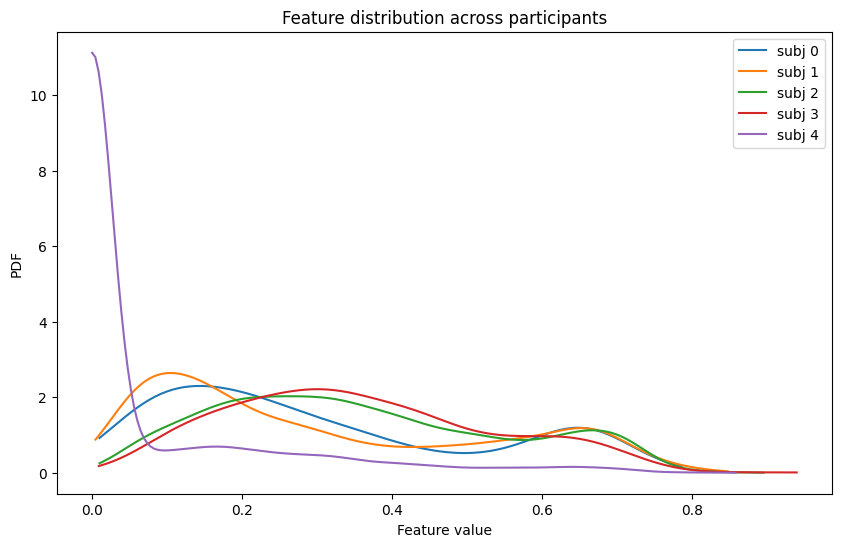

In [166]:
plt.figure(figsize=(10,6))

for i, feats in enumerate(participant_features):
    values = feats[:, 0]   # e.g. first feature (delta ch1)

    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 200)

    plt.plot(x, kde(x), label=f"subj {i}")

plt.legend()
plt.title("Feature distribution across participants")
plt.xlabel("Feature value")
plt.ylabel("PDF")
plt.show()

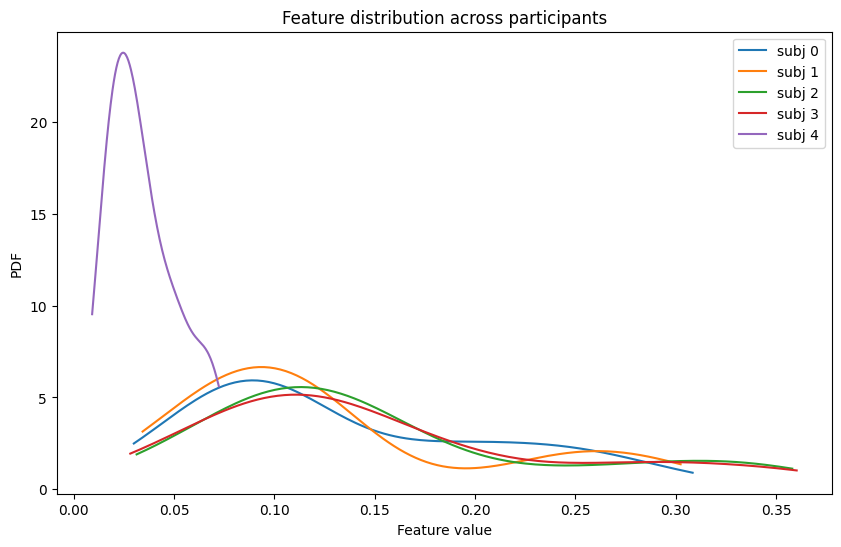

In [169]:
plt.figure(figsize=(10,6))

for i, feats in enumerate(participant_features):
    values = feats.mean(axis=0)   # aggregate per window

    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 200)

    plt.plot(x, kde(x), label=f"subj {i}")

plt.legend()
plt.title("Feature distribution across participants")
plt.xlabel("Feature value")
plt.ylabel("PDF")
plt.show()

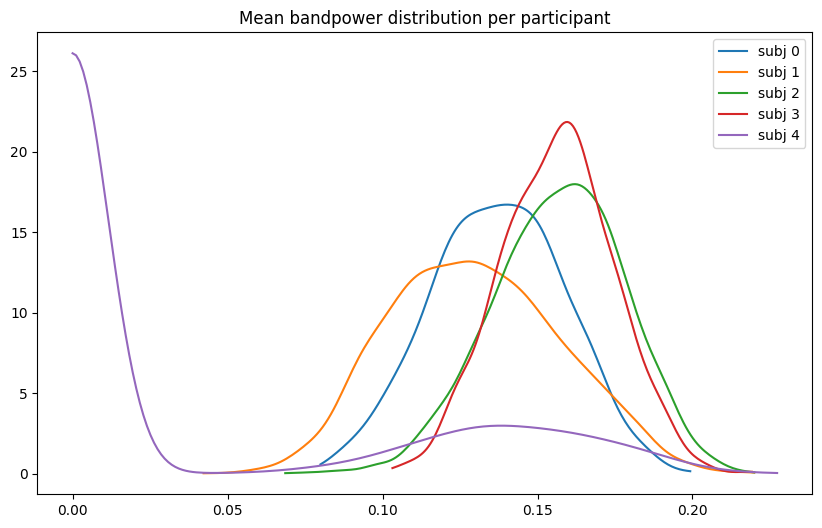

In [167]:
plt.figure(figsize=(10,6))

for i, feats in enumerate(participant_features):
    values = feats.mean(axis=1)

    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 200)

    plt.plot(x, kde(x), label=f"subj {i}")

plt.legend()
plt.title("Mean bandpower distribution per participant")
plt.show()